# 01 - Prepare the multi-city weekly target

Build `all_cities_weekly_targets.csv` with one row per `(adm3_pcode, date)` and columns:

* `all_cause_cases` -- weekly PIDSR cases summed across diseases
* `all_cause_deaths` -- weekly PSA deaths summed across diseases
* `has_pidsr_report`, `has_psa_report` -- whether the city had any reporting that week (to tell `0 cases` apart from `not reported`)


Inputs:
* `data/disease_pidsr_totals.csv`
* `data/disease_psa_totals.csv`
* `data/calendar.csv`
* `data/processed/eda/target_adm3_pcodes.json` (from `00-eda.ipynb`)

Output:
* `data/03-processed/health/all_cities_weekly_targets.csv`

In [11]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [12]:
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "data").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "data"
PROC_DIR = REPO_ROOT / "data" / "processed"
EDA_DIR  = PROC_DIR / "eda"
OUT_DIR  = PROC_DIR / "health"
OUT_DIR.mkdir(parents=True, exist_ok=True)

target_cities_path = EDA_DIR / "target_adm3_pcodes.json"
assert target_cities_path.exists(), f"Run 00-eda.ipynb first; missing {target_cities_path}"
TARGET_CITIES = sorted(json.loads(target_cities_path.read_text()))
print("Target cities:", len(TARGET_CITIES), TARGET_CITIES)

Target cities: 12 ['PH015518000', 'PH034919000', 'PH050506000', 'PH063022000', 'PH072230000', 'PH083747000', 'PH097332000', 'PH104305000', 'PH112402000', 'PH137401000', 'PH137503000', 'PH137603000']


## 1. Load raw PIDSR + PSA and filter to target cities

In [5]:
pidsr = pd.read_csv(DATA_DIR / "disease_pidsr_totals.csv", parse_dates=["date"])
psa   = pd.read_csv(DATA_DIR / "disease_psa_totals.csv",   parse_dates=["date"])

pidsr = pidsr[pidsr["adm3_pcode"].isin(TARGET_CITIES)].copy()
psa   = psa[psa["adm3_pcode"].isin(TARGET_CITIES)].copy()

print("PIDSR rows after filter:", len(pidsr), "cities:", pidsr['adm3_pcode'].nunique())
print("PSA   rows after filter:", len(psa),   "cities:", psa['adm3_pcode'].nunique())
print("PIDSR date range:", pidsr['date'].min(), "->", pidsr['date'].max())
print("PSA   date range:", psa['date'].min(),   "->", psa['date'].max())

PIDSR rows after filter: 74880 cities: 12
PSA   rows after filter: 41577 cities: 12
PIDSR date range: 2008-01-07 00:00:00 -> 2022-12-26 00:00:00
PSA   date range: 2006-01-01 00:00:00 -> 2021-12-27 00:00:00


## 2. Align dates to Monday-of-week

In [6]:
def to_monday(s):
    return (s - pd.to_timedelta(s.dt.weekday, unit="D")).dt.normalize()

pidsr["date"] = to_monday(pidsr["date"])
psa["date"]   = to_monday(psa["date"])

assert (pidsr["date"].dt.weekday == 0).all()
assert (psa["date"].dt.weekday == 0).all()

## 3. All-cause weekly aggregates

In [7]:
cases_w = (
    pidsr.groupby(["adm3_pcode", "date"], as_index=False)
    .agg(all_cause_cases=("case_total", "sum"), has_pidsr_report=("case_total", "size"))
)
cases_w["has_pidsr_report"] = (cases_w["has_pidsr_report"] > 0).astype(int)

deaths_w = (
    psa.groupby(["adm3_pcode", "date"], as_index=False)
    .agg(all_cause_deaths=("death_total", "sum"), has_psa_report=("death_total", "size"))
)
deaths_w["has_psa_report"] = (deaths_w["has_psa_report"] > 0).astype(int)

print("cases_w:", cases_w.shape, "deaths_w:", deaths_w.shape)
display(cases_w)

cases_w: (9360, 4) deaths_w: (9524, 4)


,adm3_pcode,date,all_cause_cases,has_pidsr_report
0,PH015518000,2008-01-07,9,1
1,PH015518000,2008-01-14,2,1
2,PH015518000,2008-01-21,5,1
3,PH015518000,2008-01-28,1,1
4,PH015518000,2008-02-04,2,1
...,...,...,...,...
9355,PH137603000,2022-11-28,28,1
9356,PH137603000,2022-12-05,22,1
9357,PH137603000,2022-12-12,15,1
9358,PH137603000,2022-12-19,9,1


In [8]:
display(deaths_w)

,adm3_pcode,date,all_cause_deaths,has_psa_report
0,PH015518000,2005-12-26,9,1
1,PH015518000,2006-01-02,13,1
2,PH015518000,2006-01-09,7,1
3,PH015518000,2006-01-16,4,1
4,PH015518000,2006-01-23,7,1
...,...,...,...,...
9519,PH137603000,2021-11-22,20,1
9520,PH137603000,2021-11-29,28,1
9521,PH137603000,2021-12-06,32,1
9522,PH137603000,2021-12-13,26,1


## 4. Reindex to a complete (city x week) grid

In [9]:
min_date = min(pidsr["date"].min(), psa["date"].min())
max_date = max(pidsr["date"].max(), psa["date"].max())
week_index = pd.date_range(min_date, max_date, freq="W-MON")
grid = pd.MultiIndex.from_product([TARGET_CITIES, week_index], names=["adm3_pcode", "date"]).to_frame(index=False)
print("Full grid shape:", grid.shape, "=", len(TARGET_CITIES), "cities x", len(week_index), "weeks")

target_w = (
    grid
    .merge(cases_w, on=["adm3_pcode", "date"], how="left")
    .merge(deaths_w, on=["adm3_pcode", "date"], how="left")
)

target_w["has_pidsr_report"] = target_w["has_pidsr_report"].fillna(0).astype(int)
target_w["has_psa_report"]   = target_w["has_psa_report"].fillna(0).astype(int)
target_w["all_cause_cases"]  = target_w["all_cause_cases"].fillna(0).astype(int)
target_w["all_cause_deaths"] = target_w["all_cause_deaths"].fillna(0).astype(int)

target_w = target_w.sort_values(["adm3_pcode", "date"]).reset_index(drop=True)
print("Final target shape:", target_w.shape)
target_w

Full grid shape: (10656, 2) = 12 cities x 888 weeks
Final target shape: (10656, 6)


,adm3_pcode,date,all_cause_cases,has_pidsr_report,all_cause_deaths,has_psa_report
0,PH015518000,2005-12-26,0,0,9,1
1,PH015518000,2006-01-02,0,0,13,1
2,PH015518000,2006-01-09,0,0,7,1
3,PH015518000,2006-01-16,0,0,4,1
4,PH015518000,2006-01-23,0,0,7,1
...,...,...,...,...,...,...
10651,PH137603000,2022-11-28,28,1,0,0
10652,PH137603000,2022-12-05,22,1,0,0
10653,PH137603000,2022-12-12,15,1,0,0
10654,PH137603000,2022-12-19,9,1,0,0


## 5. Sanity plots

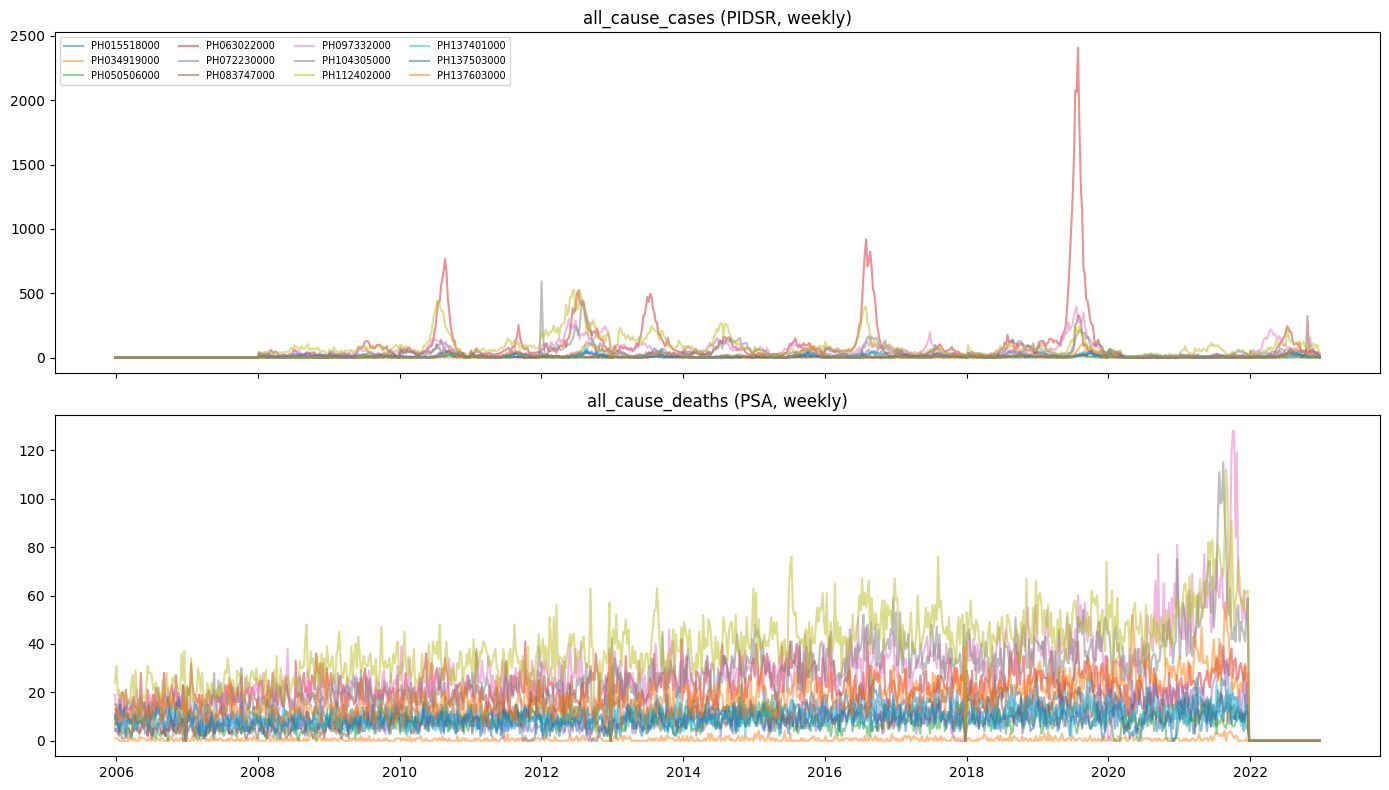

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for pcode, sub in target_w.groupby("adm3_pcode"):
    axes[0].plot(sub["date"], sub["all_cause_cases"],  alpha=0.5, label=pcode)
    axes[1].plot(sub["date"], sub["all_cause_deaths"], alpha=0.5, label=pcode)
axes[0].set_title("all_cause_cases (PIDSR, weekly)")
axes[1].set_title("all_cause_deaths (PSA, weekly)")
axes[0].legend(ncol=4, fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

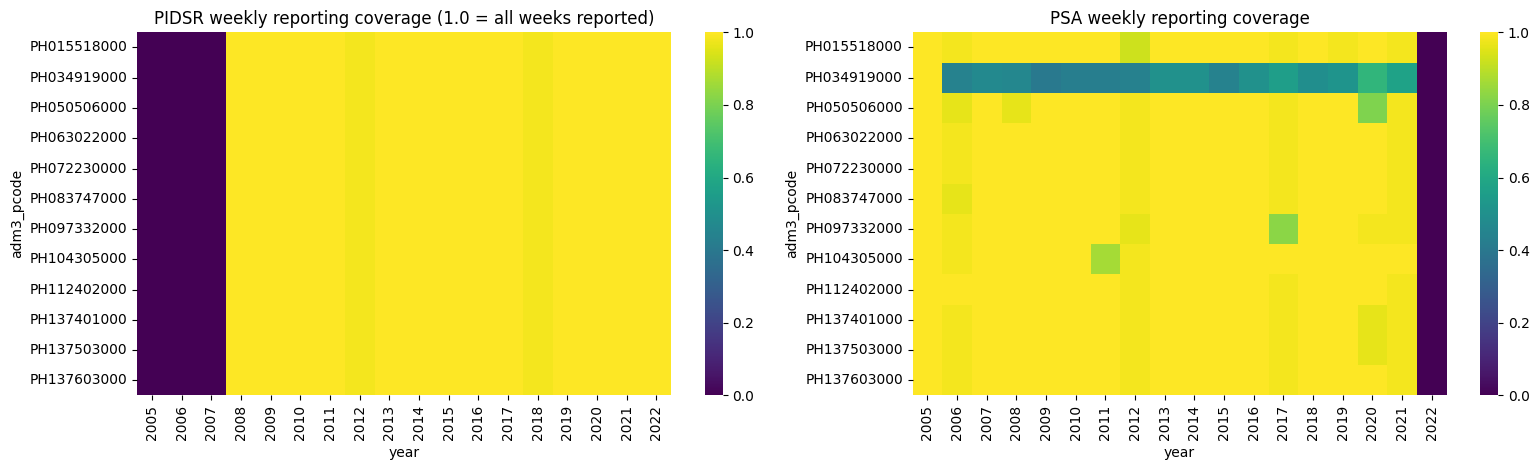

In [ ]:
tmp = target_w.copy()
tmp["year"] = tmp["date"].dt.year
coverage = (
    tmp.groupby(["adm3_pcode", "year"])[["has_pidsr_report", "has_psa_report"]]
    .mean()
    .reset_index()
)
pidsr_cov = coverage.pivot(index="adm3_pcode", columns="year", values="has_pidsr_report").astype(float)
psa_cov   = coverage.pivot(index="adm3_pcode", columns="year", values="has_psa_report").astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, max(3, 0.4 * len(pidsr_cov))))
sns.heatmap(pidsr_cov, vmin=0, vmax=1, cmap="viridis", ax=axes[0])
axes[0].set_title("PIDSR weekly reporting coverage (1.0 = all weeks reported)")
sns.heatmap(psa_cov, vmin=0, vmax=1, cmap="viridis", ax=axes[1])
axes[1].set_title("PSA weekly reporting coverage")
plt.tight_layout()
plt.show()

## 6. Write outputs

In [14]:
csv_path     = OUT_DIR / "all_cities_weekly_targets.csv"
pidsr_wpath  = OUT_DIR / "pidsr_per_disease_wide.parquet"
psa_wpath    = OUT_DIR / "psa_per_disease_wide.parquet"

target_w.to_csv(csv_path, index=False)

print("Wrote:")
print(" ", csv_path.relative_to(REPO_ROOT))

Wrote:
  data/processed/health/all_cities_weekly_targets.csv
